<h1 align="center">Física Computacional.</h1>
<h1 align="center">Semestre 2027-1</h1>

<h2>Karla Edith Santiago Pérez </h2> 

---
<h2>Profesores: </h2> 

### Sergio A. Alcalá Corona
### Rodrigo Vega Vilchis
### Joel Gómez Uribe
---


<h1 align="center">Programación para la física computacional</h1> 

## Práctica 3   Graficacion en en Python

---

### **1. Gráfica de datos experimentales**

El archivo manchasolares.txt (adjunto), contiene el número observado de manchas solares en el Sol en cada mes desde enero de 1749. El archivo contiene dos columnas de números, la primera es el mes y la segunda el número de manchas solares.

(a) Escribe un programa que lea los datos y haga una gráfica de las manchas solares en función del tiempo.



In [135]:
import numpy as np #manejar arreglos numericos 
import matplotlib.pyplot as plt #grafica

In [136]:

datos = np.loadtxt('manchasolares.txt') # lee el archivo txt en en la carpeta
tiempo = datos[:, 0]  # columna 0 = meses
manchas = datos[:, 1] # columna 1 = numero de manchas
print("Datos cargados:", len(datos))

Datos cargados: 3143


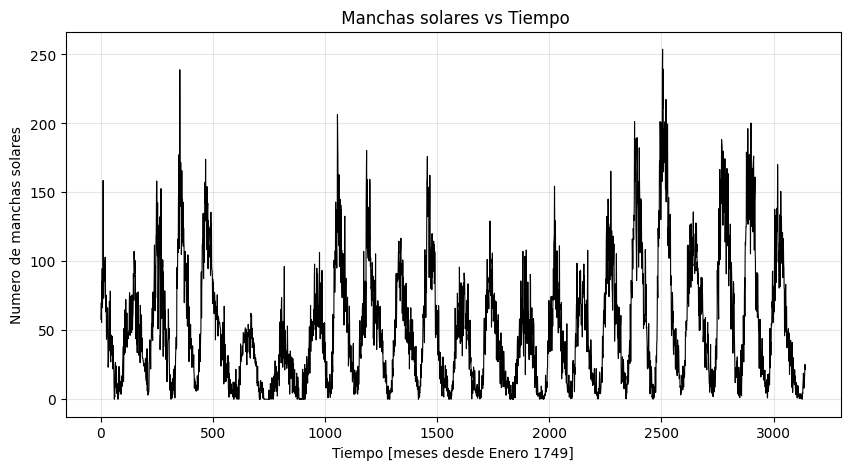

In [137]:
plt.figure(figsize=(10,5)) # Crea figura de 10 pulgadas ancho x 5 alto, ancha porque son datos de 1749 a ahora, mas de 3000 meses, necesita espacio horizontal

plt.plot(tiempo, manchas, 'k-', linewidth=0.8) #  Grafica manchas solares vs tiempo. manchas = numero de manchas. 'k-' = linea negra continua, linewidth=0.8 = linea delgada para que se vean los picos sin que se haga una mancha negra gruesa

plt.xlabel('Tiempo [meses desde Enero 1749]') #  Etiqueta eje x  en meses desde 1749

plt.ylabel('Numero de manchas solares') # Etiqueta eje y, es la variable que se mide

plt.title(' Manchas solares vs Tiempo') # Titulo de la grafica 

plt.grid(True, alpha=0.3) #  Rejilla tenue alpha=0.3 para poder leer valores sin que tape la curva, hay muchos picos

plt.show() # Muestra la figura

(b) Modifica tu programa para mostrar solo los primeros 1000 datos (experimentales) en la gráfica.

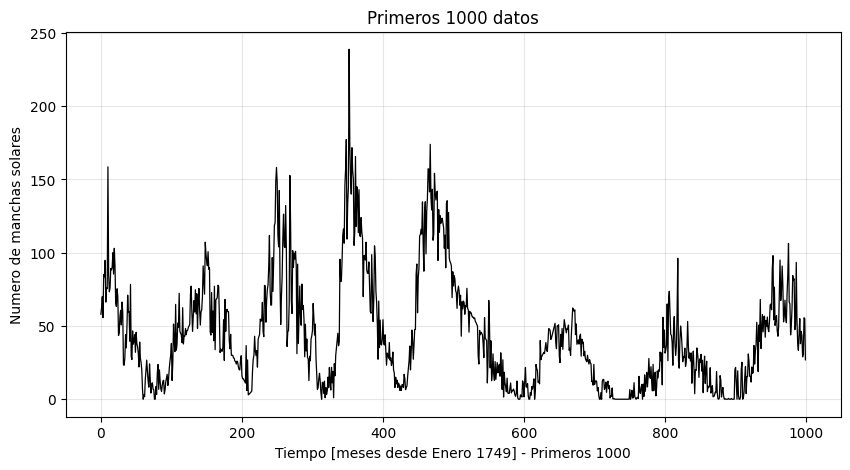

In [138]:
plt.figure(figsize=(10,5))
plt.plot(tiempo[:1000], manchas[:1000], 'k-', linewidth=0.9)
plt.xlabel('Tiempo [meses desde Enero 1749] - Primeros 1000')
plt.ylabel('Numero de manchas solares')
plt.title('Primeros 1000 datos')
plt.grid(True, alpha=0.3)
plt.show()

 Aqui vemos que los primeros 1000 meses se ve que mes a mes sube y baja bruscamente (picos de 0 a 150 en un solo mes). Eso no es el Sol real variando tan rápido, es ruido de medición y tambien variabilidad mensual. Por eso se ve asi de peliditp.

(c) Modifica nuevamente tu programa para calcular y graficar la media móvil definida por:

$$Y_k = \frac{1}{2r+1} \sum_{m=-r}^{r} y_{k+m}$$

donde $r = 5$ (en este caso) y $y_k$ son los números de manchas solares.

El programa debe graficar tanto los datos originales como la media móvil en el mismo gráfico, sólo sobre los primeros 1000 datos.

In [139]:
# Cargamos el archivo con dos columnas
datos = np.loadtxt('manchasolares.txt')
tiempo = datos[:, 0]  # columna 0 = tiempo en meses
manchas = datos[:, 1] # columna 1 = numero de manchas

In [140]:
# Solo tomamos primeros 1000 
N = 1000
t_1000 = tiempo[:N]
y_1000 = manchas[:N]

In [141]:
# Definimos r y tamanio de ventana
r = 5
ventana = 2*r + 1  # ventana = 11, segun la formula 

# Creamos filtro de promedio de 11 unos dividido entre 11
filtro = np.ones(ventana) / ventana

# Aplicamos convolucion para calcular media movil
# mode='same' regresa mismo largo que datos originales
media_movil = np.convolve(y_1000, filtro, mode='same')

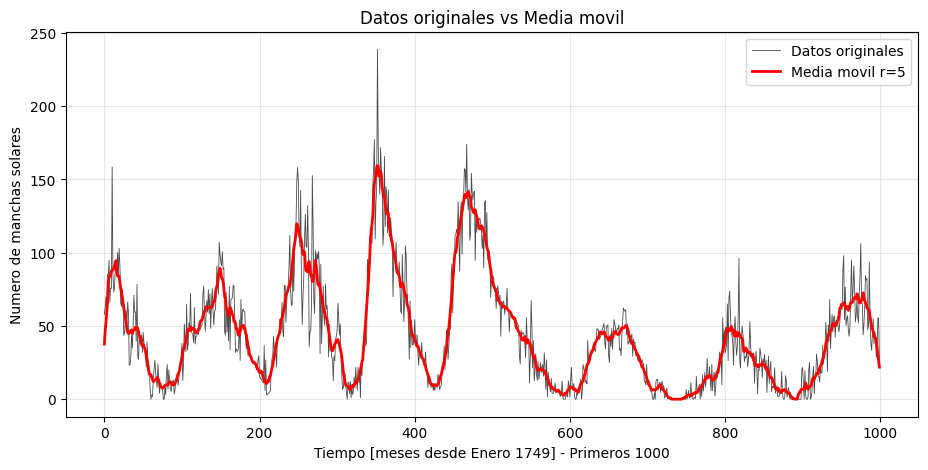

In [143]:
# Graficamos ambos en mismo grafico
plt.figure(figsize=(11,5))
plt.plot(t_1000, y_1000, 'k-', linewidth=0.6, alpha=0.7, label='Datos originales')
plt.plot(t_1000, media_movil, 'r-', linewidth=2, label=f'Media movil r={r}')
plt.xlabel('Tiempo [meses desde Enero 1749] - Primeros 1000')
plt.ylabel('Numero de manchas solares')
plt.title('Datos originales vs Media movil')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **2. La gráfica de Feigenbaum (caos determinista)**

El concepto de **caos determinista** viene del **efecto mariposa** planteado por Edward Lorenz en 1972 en su charla "¿El aleteo de una mariposa en Brasil puede provocar un tornado en Texas?".

Aunque un sistema sea determinista, es muy sensible a pequeñas perturbaciones en las condiciones iniciales y por eso su comportamiento parece aleatorio. Ocurre en sistemas climáticos, dinámica de fluidos y otros sistemas físicos complejos.

El ejemplo más simple es el **mapeo logístico**, definido por:

$$x_{n+1} = r x_n (1 - x_n)$$

Donde $r$ es una constante. Se toma un valor inicial $x_0$ (ej. $x_0 = 1/2$), se calcula $x_{n+1}$ y ese valor se vuelve a introducir en la ecuación de forma iterativa.

(i) El valor se establece en un número fijo y permanece allí. Esto se llama **punto fijo**. Por ejemplo, $x_n = 0$ es siempre un punto fijo del mapeo logístico. (Si se pone $x_n = 0$ en el lado derecho, $x_{n+1} = 0$ en el lado izquierdo).


In [144]:

# funcion del mapeo logistico
def logistico(x, r):
    return r * x * (1 - x)

In [145]:



# valores de r para cada caso
casos = {
    "punto fijo r=2.0": 2.0,
    "periodico r=3.2 (periodo 2)": 3.2,
    "caos r=3.9": 3.9
}

x0 = 0.5 # condicion inicial 
N = 100 # iteraciones



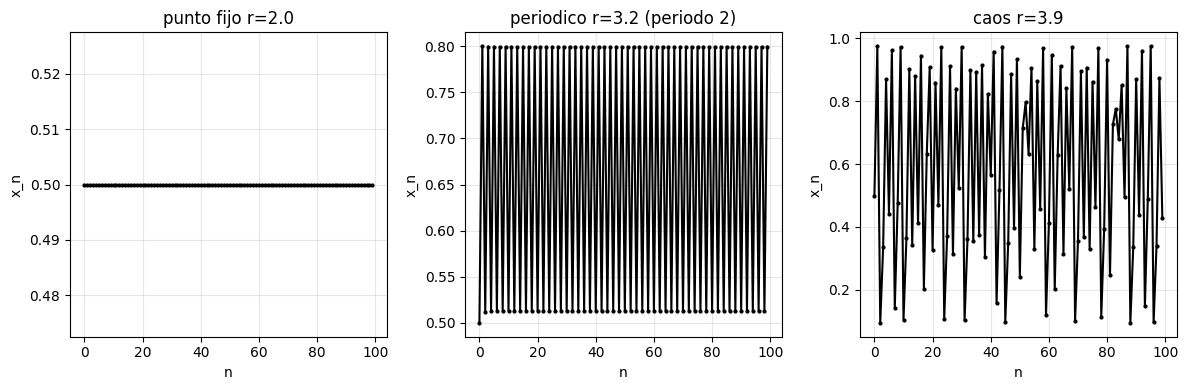

In [146]:
plt.figure(figsize=(12,4)) #Crea figura  para que quepan 3 graficas lado a lado sin que se amontonen
#  Recorre el diccionario casos = {"r=2.5":2.5, "r=3.2":3.2,...}.
#enumerate(...,1) te da i=1,2,3 para el subplot y (titulo,r) para el titulo y el parametro r
# . Empieza en 1 porque subplot empieza en 1, no en 0
for i, (titulo, r) in enumerate(casos.items(), 1): 
    x = np.zeros(N) # 3. Crea arreglo de N ceros para guardar la serie x_n. N=50 tipico. se necesita guardar para graficar despues
    x[0] = x0 # 4. Condicion inicial x0=0.5 es el primer punto de la iteracion
    for n in range(N-1): # Itera N-1 veces porque ya tienes x[0]. Va de n=0 a N-2. En cada vuelta se calcula el siguiente
        x[n+1] = logistico(x[n], r) # Aplica el mapa logistico .

    plt.subplot(1,3,i) #  Divide la figura en 1 fila, 3 columnas y activa la subgrafica i. i=1 es izquierda, i=2 centro, i=3 derecha
    plt.plot(x, 'k-', marker='o', markersize=2) # Grafica x_n vs n. 'k-' = linea negra continua, marker='o' = puntitos circulares, markersize=2 = puntos chiquitos para que se vea la evolucion
    plt.title(titulo) #  Pone titulo como "r=2.5: punto fijo" etc, para identificar cada caso
    plt.xlabel('n') #  Eje x es numero de iteracion n
    plt.ylabel('x_n') #  Eje y es valor de la poblacion x_n
    plt.grid(True, alpha=0.3) #  Rejilla tenue alpha=0.3 para leer valores sin que tape la grafica

plt.tight_layout() #  Ajusta espacios entre subgraficas para que no se encimen titulos y ejes
plt.show() #  Muestra la figura en pantalla

(ii) No se establece en un solo valor, sino que se establece en un patrón periódico, rotando alrededor de un conjunto de valores, digamos cuatro valores, repitiéndose en secuencia una y otra vez. Esto se llama **órbita** (en este caso de **periodo 4**) o **ciclo límite**.

In [147]:

r = 3.5#  Parametro de control r, el sistema entra en ciclo de periodo 4 
x0 = 0.5 # Condicion inicial x0
N = 170 # Numero de iteraciones a graficar

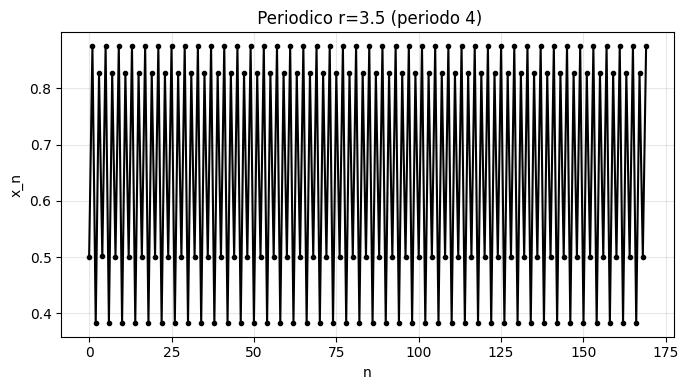

[0.38281968 0.82694071 0.50088421 0.87499726 0.38281968 0.82694071
 0.50088421 0.87499726]


In [149]:


#  Arreglo para guardar valores de x_n
x = np.zeros(N)
x[0] = x0 # primer valor

#  Iteramos el mapeo logistico
# Este for aplica la formula 100 veces
for n in range(N-1):
    x[n+1] = logistico(x[n], r)

# Graficamos serie temporal
plt.figure(figsize=(7,4))
plt.plot(x, 'k-', marker='o', markersize=3) # k- = linea negra
plt.title(' Periodico r=3.5 (periodo 4)')
plt.xlabel('n')
plt.ylabel('x_n')
plt.grid(True, alpha=0.3) # rejilla para mejor lectura
plt.tight_layout()
plt.show()

# Imprimimos ultimos 8 valores para comprobar periodo 4
# Deben repetirse 4 valores: 0.5008, 0.8749, 0.3828, 0.8269
print(x[-8:])

(iii) Todo enloquece. El mapeo genera una secuencia aparentemente aleatoria de números que parecen no tener patrón ni razón (ni ton ni son). Esto es el **caos determinista**. "Caos" porque realmente parece caótico y "determinista" porque aunque los valores parecen aleatorios, no lo son. Son a todas luces, totalmente predecibles, porque se obtienen mediante una simple ecuación y el comportamiento está determinado, aunque no lo parezca.


In [150]:

def logistico(x, r): #  Definimos la funcion del mapeo logistico
    return r * x * (1 - x) # Es la ecuacion determinista que genera caos


r = 3.9 # Parametro de control r en regimen caotico
# para r cercano a 4 entramos en caos
# Usamos r=3.9 para caos total
x0 = 0.5 # Condicion inicial 
N = 100 # Numero de iteraciones n
# Con N=100 ya se ve que no hay patron periodico


In [151]:
# Creamos arreglo para guardar todos los x_n
x = np.zeros(N) # np.zeros crea 100 ceros donde guardaremos la historia
x[0] = x0 # el primer elemento es la condicion inicial

#  Iteramos el mapeo logistico
# Este for es la evolucion temporal determinista
# Calcula x1 a partir de x0, x2 a partir de x1, etc.
for n in range(N-1):
    x[n+1] = logistico(x[n], r)



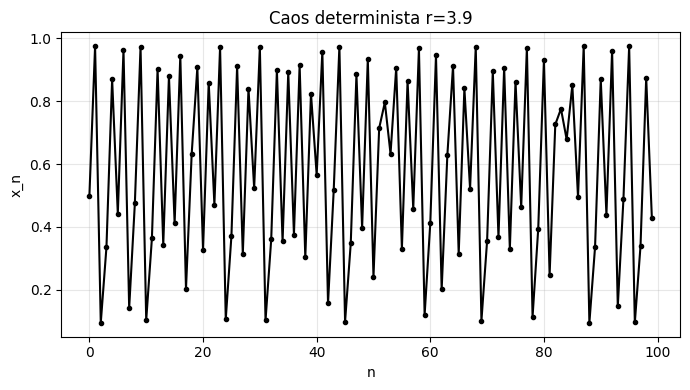

[0.87063281 0.43926215 0.96061256 0.14756067 0.49056742 0.974653
 0.09634765 0.33955266 0.87460094 0.42772914]


In [152]:
# Graficamos serie temporal 
plt.figure(figsize=(7,4)) # tamano de la figura
plt.plot(x, 'k-', marker='o', markersize=3) # k- = linea negra
plt.title('Caos determinista r=3.9') # titulo del inciso
plt.xlabel('n') # eje x = numero de iteracion
plt.ylabel('x_n') # eje y = valor del mapeo
plt.grid(True, alpha=0.3) # rejilla para lectura
plt.tight_layout() # ajusta margenes
plt.show() # muestra grafica

# Comprobacion numerica de caos
# Imprimimos ultimos 10 valores
#  aqui no se repite ninguno
print(x[-10:])

### Responde a las siguientes preguntas:

**(a)** Apóyate en el programa que vimos en clase y escribe un programa que muestre el comportamiento del mapeo logístico mediante una gráfica.



In [174]:
#definimos las mismas librerias
import numpy as np
import matplotlib.pyplot as plt

In [175]:

def logistico(x, r):# Funcion logistica
    return r * x * (1 - x) 


r_min = 2.5 # Rango de r a explorar, el caos interesante es de 2.5 a 4.0
r_max = 4.0
num_r = 1000  # cuantos valores de r probamos,

# Iteraciones

N_total = 1000  # N_total = 1000 iteraciones por cada r
N_trans = 900  # N_trans = 900 iteraciones de transitorio

In [176]:
#  Vector de valores de r
r_vals = np.linspace(r_min, r_max, num_r)

#  Listas para guardar puntos para graficar
r_plot = []  # aqui guardamos el r repetido
x_plot = []  # aqui guardamos el x correspondiente

#  Condicion inicial fija
x0 = 0.5

#  Barrido en r - este es el doble for 
for r in r_vals:
    x = x0
    # iteramos 1000 veces para este r
    for n in range(N_total):
        x = logistico(x, r)
        # solo guardamos despues del transitorio
        if n >= N_trans:
            r_plot.append(r)
            x_plot.append(x)

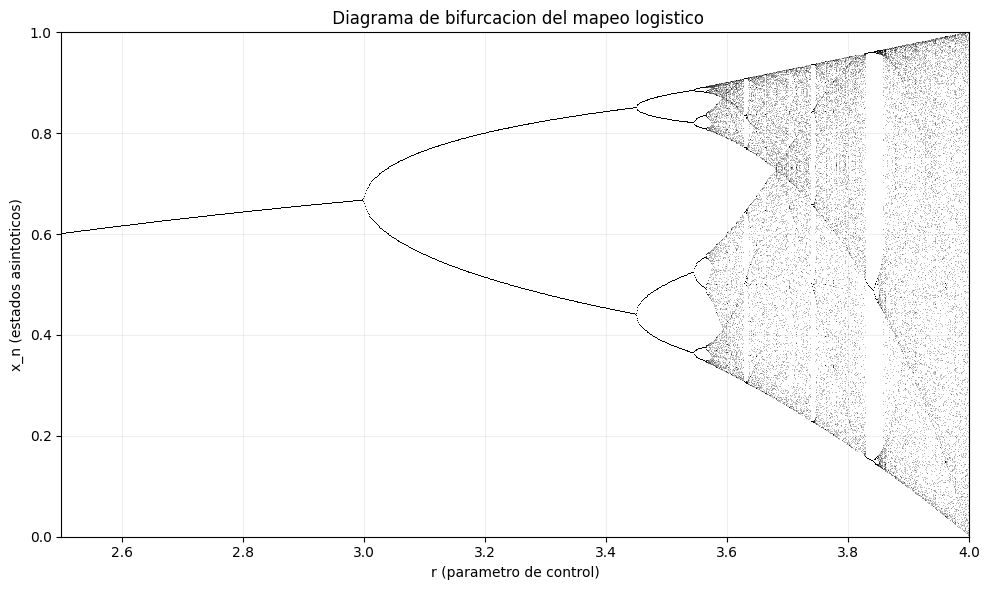

In [177]:
#  Graficamos diagrama de Feigenbaum
plt.figure(figsize=(10,6))
plt.plot(r_plot, x_plot, ',k', alpha=0.25, markersize=1) # ,k = punto negro
plt.title(' Diagrama de bifurcacion del mapeo logistico')
plt.xlabel('r (parametro de control)')
plt.ylabel('x_n (estados asintoticos)')
plt.xlim(r_min, r_max)
plt.ylim(0, 1)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

**Diagrama de bifurcacion**


Con este diagrama ya se ve todo lo de la parte (a).

De 2.5 a 3.0 se ve una sola linea, eso es el punto fijo del inciso (i), se queda en un solo valor.

En r=3.0 se abre en dos, es el periodo 2.

En r=3.45 aprox se abre en cuatro, que es el periodo 4 que grafique antes con los valores 0.50, 0.87, 0.38, 0.82 que se van repitiendo.

Despues en 3.54 se abre en 8, 16, 32 y ya en 3.57 se hace como una nube negra, eso ya es el caos del inciso (iii), parece aleatorio pero todo sale de la misma formula.

Y las partes blancas que se ven como en 3.83 son ventanas donde vuelve a haber orden dentro del caos.

**(b)** De acuerdo a tu gráfica, ¿a qué valor de $r$ el sistema pasa de un comportamiento ordenado (puntos fijos o ciclos límite) a un comportamiento caótico? A este punto a veces se le llama "el borde del caos".


Tu programa debería generar la distintiva gráfica que parece un árbol inclinado hacia un lado. Esta famosa imagen se llama **Gráfica de Feigenbaum**, en honor a su descubridor Mitchell Feigenbaum.

In [157]:
# Función logística
def logistico(x, r):
    return r * x * (1 - x)

# Rango de r de 1 a 4 en pasos de 0.01 
r_min = 1
r_max = 4
dr = 0.01
r_vals = np.arange(r_min, r_max, dr)

# Iteraciones 
N_estable = 1000  # mil veces para establecerse
N_plot = 1000     # mil veces para graficar x_infinito

#  Condición inicial x=1/2 
x0 = 0.5

In [158]:
# Doble ciclo
r_plot = []   # aqui para que siempre empiece vacio
x_plot = []   

for r in r_vals:
    x = x0
    # primero 1000 iteraciones para llegar a atractor
    for i in range(N_estable):
        x = logistico(x, r)
    # ahora otras 1000 y grafica los puntos (r, x_infinito)
    for i in range(N_plot):
        x = logistico(x, r)
        r_plot.append(r)
        x_plot.append(x)

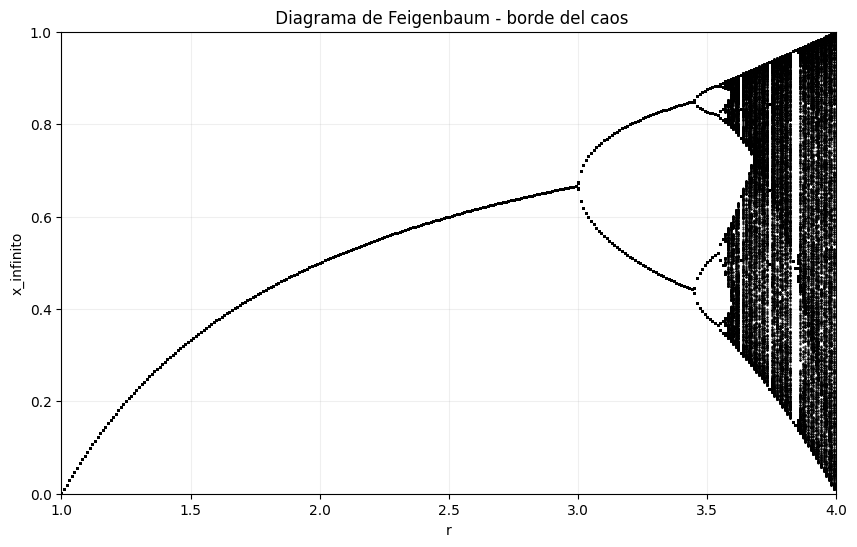

In [159]:
# Gráfica de dispersión con puntos
# se usa "k." o "ko" o scatter, aqui uso puntos negros pequeños
plt.figure(figsize=(10,6))
plt.plot(r_plot, x_plot, 'k.', markersize=1) # k. = punto negro
# o  plt.scatter(r_plot, x_plot, s=1, c='k', alpha=0.25)
plt.title(' Diagrama de Feigenbaum - borde del caos')
plt.xlabel('r')
plt.ylabel('x_infinito')
plt.xlim(1,4)
plt.ylim(0,1)
plt.grid(True, alpha=0.2)
plt.show()

**borde del caos**

De acuerdo a la grafica, el sistema pasa de ordenado a caotico en r=3.57 aprox.

Antes de ese valor se ven lineas bien definidas que son puntos fijos y ciclos limite (1, 2, 4, 8...). Despues de 3.57 se ve como una mancha negra, eso es el caos, ya no hay un numero finito de valores sino infinitos.

A ese punto se le llama el borde del caos y es r=3.5699 aprox. Es donde termina la cascada de duplicacion de periodo y empieza el caos determinista. Se puede ver en el diagrama donde las lineas dejan de separarse y se juntan en una nube.

**(c) Opcional :** Hay otra forma para calcular el diagrama de Feigenbaum, que puede ser más claro y rápido, dado que hace uso de la capacidad de Python para realizar aritmética con arreglos completos. Crear un arreglo `r` que contenga cada valor distinto de $r$, $[1.0, 1.01, 1.02, ...]$. Crea otro arreglo $x$ del mismo tamaño para guardar los valores correspondientes de $x$, establecidos inicialmente en $0.5$; finalmente realiza una iteración del mapeo logístico para todos los valores de $r$ a la vez, con una sola instrucción de la forma:

$$x = r * x * (1 - x)$$

y compárala con tu programa anterior.

In [160]:
# Arreglo r que contenga cada valor distinto de r [1.0, 1.01, 1.02, ...]
#  con paso 0.01
r_min = 1.0
r_max = 4.0
dr = 0.01
r = np.arange(r_min, r_max, dr)  # r es vector de 300 valores

#  Otro arreglo x del mismo tamaño para guardar valores correspondientes
# Inicialmente en 0.5 
x = np.full_like(r, 0.5)  # x = [0.5, 0.5, 0.5, ...] mismo largo que r

# Iteraciones igual que antes
N_estable = 1000
N_plot = 1000

In [161]:

# Esta sola linea hace 300 mapeos logisticos a la vez
for i in range(N_estable):
    x = r * x * (1 - x)

#  Ahora otras 1000 para graficar y guardar (r, x_infinito)
# Preparamos listas para el plot
r_plot = []
x_plot = []

for i in range(N_plot):
    x = r * x * (1 - x)  # una sola instruccion para todos los r a la vez
    r_plot.extend(r)     # guardamos todos los r
    x_plot.extend(x)     # guardamos todos los x correspondientes

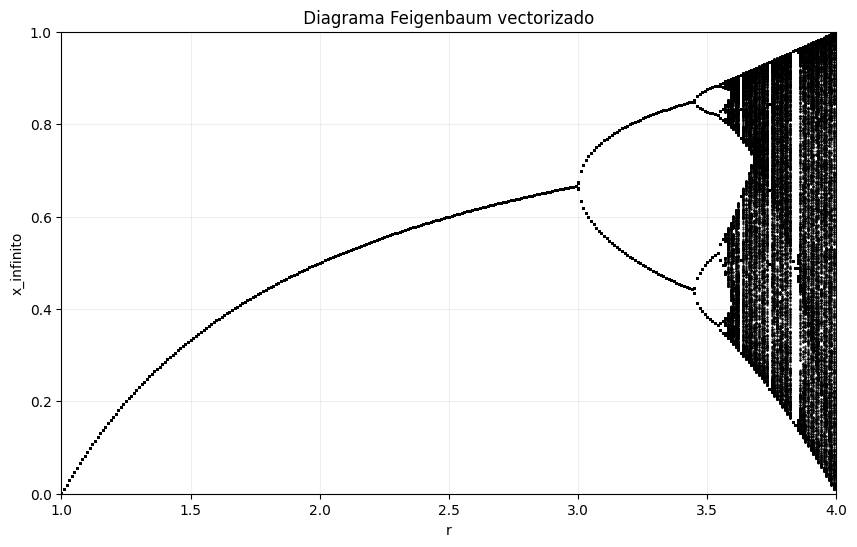

In [162]:
# Grafica de dispersion con puntos
plt.figure(figsize=(10,6))
plt.plot(r_plot, x_plot, 'k.', markersize=1,)
plt.title(' Diagrama Feigenbaum vectorizado ')
plt.xlabel('r')
plt.ylabel('x_infinito')
plt.xlim(1,4)
plt.ylim(0,1)
plt.grid(True, alpha=0.2)
plt.show()

**forma vectorizada**

Se creo un arreglo r = [1.0, 1.01, ..., 4.0] y un arreglo x = [0.5, 0.5, ...] del mismo largo. Cada posicion i representa un sistema logistico independiente con su propio r.

Con la instruccion x = r*x*(1-x) se evoluciona los 300 sistemas simultaneamente. Despues de 1000 pasos todos llegaron a su atractor (punto fijo, ciclo o caos). Luego se hizo otros 1000 pasos y se va guardando todos los pares (r, x) para graficar.

Al final da la misma grafica que en el inciso (b) pero es mas rapido porque no usamos for para r.

### 3. El conjunto de Mandelbrot (fractal)

Es un **fractal** infinitamente ramificado: estructura dentro de estructura.

Se define con números complejos con la ecuación iterativa:

$$z_{n+1} = z_n^2 + c, \quad z_n, c \in \mathbb{C}$$

Muy similar al mapeo logístico: se toma un valor inicial $z_0 = 0$ y un valor de $c = x + iy$ fijo. Se itera $z_{n+1}$ una y otra vez.

**Definición del conjunto:**
* Si para un $c$ dado, al iterar, la magnitud $|z_n| > 2$ en algún momento, entonces **$c$ NO está** en el conjunto de Mandelbrot (escapa al infinito).
* Si $|z_n| \le 2$ siempre, entonces **$c$ SÍ está** en el conjunto.

En la práctica no se itera infinito, con ~100 iteraciones es suficiente. Si en 100 iteraciones $|z_n|$ no ha excedido 2, se considera que está dentro.

---



**(a) Imagen básica N x N:**
Escribe un programa para crear una imagen del conjunto de Mandelbrot realizando la iteración para todos los valores de $c = x + iy$ en una cuadrícula de $N \times N$ que abarque la región donde $-2 \le x \le 2$ y $-2 \le y \le 2$. Haz una gráfica de densidad (density plot) en el que los puntos de la cuadrícula dentro del conjunto de Mandelbrot estén coloreados en negro y los de afuera estén coloreados en blanco.

In [163]:
import numpy as np
import matplotlib.pyplot as plt

In [164]:
#  Region 
x_min, x_max = -2, 2
y_min, y_max = -2, 2

#  N x N cuadricula.

N = 800 # prueba rapida, luego cambia a 800

# Numero de iteraciones 
max_iter = 100

In [165]:
# Crear N valores de x entre -2 y 2
x = np.linspace(x_min, x_max, N)
y = np.linspace(y_min, y_max, N)

#  Crear malla 2D con todos los c = x + i*y
# X[i,j] = x, Y[i,j] = y
X, Y = np.meshgrid(x, y)

#  Construir c complejo: parte real X + parte imaginaria i*Y
c = X + 1j * Y # c es arreglo N x N de complejos

# Inicializar z en 0 como dice definicion z0=0, mismo tamaño que c
z = np.zeros_like(c, dtype=complex)

#  Arreglo para guardar si esta en conjunto: True = aun no escapa
# Al inicio todos son True (todos candidatos a estar dentro)
en_conjunto = np.full(c.shape, True, dtype=bool)

In [166]:
# Iterar max_iter veces
for i in range(max_iter):
    # Solo actualiza los que aun no han escapado
    # Si ya escapo |z|>2, ya no se sigue iterando
    z[en_conjunto] = z[en_conjunto]**2 + c[en_conjunto]

    #  Ver cuales se acaban de escapar: |z| > 2
    # np.abs(z) es la magnitud |z_n| 
    escaparon = np.abs(z) > 2

    # Los que escaparon ya no estan en conjunto aplica False
    en_conjunto[escaparon] = False
    # una vez que es False se queda False, ya no se actualiza

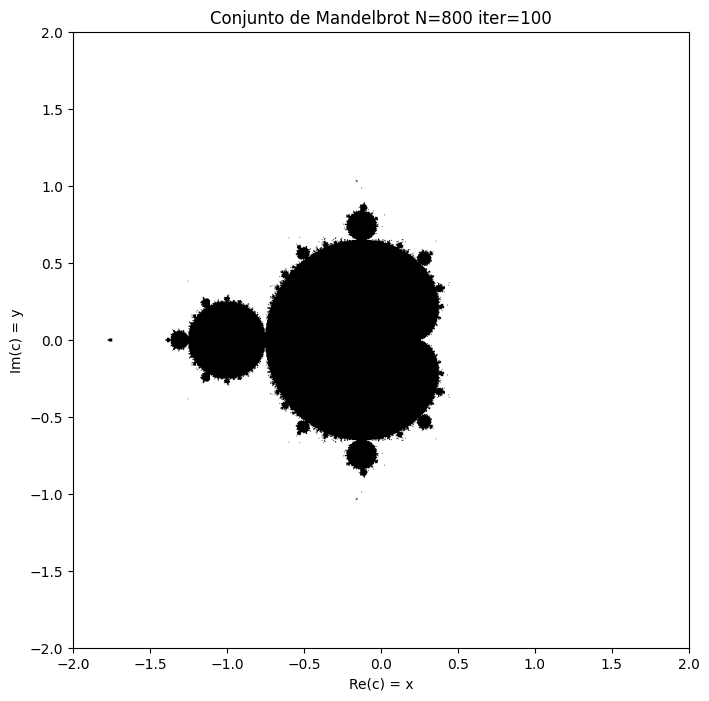

In [167]:
# Crear figura
plt.figure(figsize=(8,8))

# Graficar con imshow: negro donde en_conjunto=True, blanco donde False
# en_conjunto es booleano, imshow lo muestra como 0 y 1
# cmap='binary' : 0=blanco, 1=negro. Usamos binary_r o invertimos
# extent para poner ejes en -2 a 2 como pide
plt.imshow(en_conjunto, cmap='binary', extent=[x_min, x_max, y_min, y_max], origin='lower')

#  Detalles
plt.title(f'Conjunto de Mandelbrot N={N} iter={max_iter}')
plt.xlabel('Re(c) = x')
plt.ylabel('Im(c) = y')
plt.show()

**Conjunto de Mandelbrot**

Se realizo el conjunto de Mandelbrot en la region -2 <= x <= 2 y -2 <= y <= 2 con una cuadricula N x N. Primero se probo con N=100 que se ve pixelado pero rapido. Luego se genero la imagen final con N=800 e iter=100.

Se itera z_{n+1}=z_n^2 + c con z0=0. Si |z_n|>2 se considera que escapa y no pertenece al conjunto (blanco). Si no escapa en 100 iteraciones se considera dentro (negro). En la imagen final se distingue el cardioide principal y los bulbos secundarios caracteristicos del fractal.

 **(b) Opcional extra - color:** 
 Programar otra variante del mismo ejercicio que puede producir imágenes sorprendentes. En lugar de colorear los puntos solo en blanco o negro, colorea los puntos de acuerdo con el número de iteraciones de la ecuación antes de que $|z_n|$ sea mayor que 2 (o bien el número máximo de iteraciones si es que $|z_n|$ nunca llega a ser mayor que 2). Si usas alguno de los esquemas más coloridos que Python proporciona para las gráficas de densidad, como "hot" o "jet", puedes crear algunas imágenes muy espectaculares. Otra variante interesante es colorear según el logaritmo del número de iteraciones, lo que ayuda a revelar parte de la estructura más fina fuera del conjunto.

In [168]:
#parametros 
# Region igual que en (a)
x_min, x_max = -2, 2
y_min, y_max = -2, 2
N = 800 # para que se vea bien el color, con 100 se ve pixelado
max_iter = 100 #  si escapa antes de 100

In [169]:
#Crear malla de c
x = np.linspace(x_min, x_max, N)
y = np.linspace(y_min, y_max, N)
X, Y = np.meshgrid(x, y)
c = X + 1j * Y # c complejo N x N

z = np.zeros_like(c, dtype=complex) # z0=0

# Nuevo: arreglo para guardar numero de iteraciones antes de escapar
# Al inicio todo 0 = no ha escapado
iter_count = np.zeros(c.shape, dtype=int)

# Mascara de los que aun no escapan
vivos = np.full(c.shape, True, dtype=bool)

In [170]:
#Iteracion guardando cuando escapa
for i in range(max_iter):
    #  Solo actualiza los vivos
    z[vivos] = z[vivos]**2 + c[vivos]

    #  De los vivos, cuales acaban de escapar |z|>2
    recien_escaparon = (np.abs(z) > 2) & vivos

    # Guarda en que iteracion escaparon
    # Solo los que recien escapan y aun no tenian iter_count
    iter_count[recien_escaparon] = i

    # Esos ya no son vivos
    vivos[recien_escaparon] = False

# Los que nunca escaparon son el conjunto, les dejamos max_iter
iter_count[vivos] = max_iter

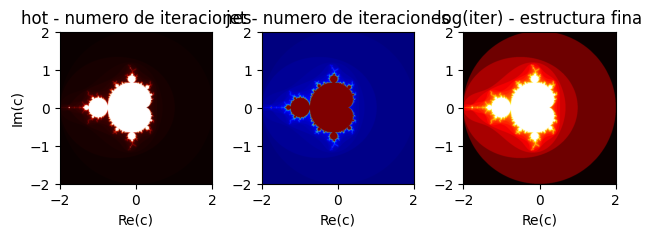

In [171]:
# Graficas de densidad con colormaps hot / jet
#  plt.figure(figsize=(15,5))

# Colormap hot
plt.subplot(1,3,1)
plt.imshow(iter_count, cmap='hot', extent=[x_min,x_max,y_min,y_max], origin='lower')
plt.title('hot - numero de iteraciones')
plt.xlabel('Re(c)')
plt.ylabel('Im(c)')

# Colormap jet
plt.subplot(1,3,2)
plt.imshow(iter_count, cmap='jet', extent=[x_min,x_max,y_min,y_max], origin='lower')
plt.title('jet - numero de iteraciones')
plt.xlabel('Re(c)')

# Logaritmo del numero de iteraciones - revela estructura fina fuera
plt.subplot(1,3,3)
# log(iter+1) para que no de log(0). +1 evita error
log_iter = np.log(iter_count + 1)
plt.imshow(log_iter, cmap='hot', extent=[x_min,x_max,y_min,y_max], origin='lower')
plt.title('log(iter) - estructura fina')
plt.xlabel('Re(c)')

plt.tight_layout()
plt.show()

**Coloreado por iteraciones**

Si un c esta muy lejos del Mandelbrot, por ejemplo c=1.5+1.5i, su |z| supera 2 en 1 o 2 iteraciones, es rapido. Si esta justo en la frontera, tarda 80-90 iteraciones en superar 2, es lento. Esa diferencia de velocidad es la que se colorea.

Al usar hot, los puntos rapidos se ven de un color y los lentos de otro, y el interior que nunca escapa se ve negro porque le pusimos max_iter. Asi aparece el halo de colores alrededor del Mandelbrot.

Al usar log(iter), se resalta la estructura fina afuera del conjunto que en blanco y negro no se ve, que son los filamentos del fractal.

In [172]:
#Iteracion guardando cuando escapa
for i in range(max_iter):
    # Solo actualiza los vivos
    z[vivos] = z[vivos]**2 + c[vivos]

    # De los vivos, cuales acaban de escapar |z|>2
    recien_escaparon = (np.abs(z) > 2) & vivos

    # Solo los que recien escapan y aun no tenian iter_count
    iter_count[recien_escaparon] = i  # Guarda en que iteracion escaparon

    # Esos ya no son vivos
    vivos[recien_escaparon] = False

# Los que nunca escaparon son el conjunto, les dejamos max_iter
iter_count[vivos] = 0

En hot normalmente el Mandelbrot se deja en negro. Para eso en vez de iter_count[vivos] = max_iter cambiamos a  iter_count[vivos] = 0, así el interior queda negro y el exterior con colores fuego.

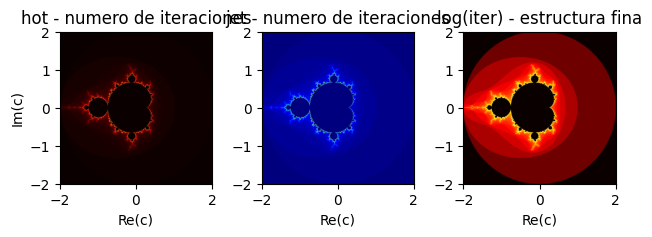

In [173]:
# Graficas de densidad con colormaps hot / jet
#  plt.figure(figsize=(15,5))

# Colormap hot
plt.subplot(1,3,1)
plt.imshow(iter_count, cmap='hot', extent=[x_min,x_max,y_min,y_max], origin='lower')
plt.title('hot - numero de iteraciones')
plt.xlabel('Re(c)')
plt.ylabel('Im(c)')

# Colormap jet
plt.subplot(1,3,2)
plt.imshow(iter_count, cmap='jet', extent=[x_min,x_max,y_min,y_max], origin='lower')
plt.title('jet - numero de iteraciones')
plt.xlabel('Re(c)')

#  Logaritmo del numero de iteraciones - revela estructura fina fuera
plt.subplot(1,3,3)
log_iter = np.log(iter_count + 1) # log(iter+1) para que no de log(0). +1 evita error
plt.imshow(log_iter, cmap='hot', extent=[x_min,x_max,y_min,y_max], origin='lower')
plt.title('log(iter) - estructura fina')
plt.xlabel('Re(c)')

plt.tight_layout()
plt.show()

**Mandelbrot coloreado**

Se coloreo el conjunto segun el numero de iteraciones antes de que |z|>2. Si un c esta lejos del conjunto escapa rapido en 1a 2 iteraciones, si esta cerca de la frontera tarda 80 a 90 iteraciones. Esa diferencia de velocidad es la que se colorea.

hot: interior negro y borde rojo fuego, se ve la costa del fractal.
jet: interior negro, afuera azul con el borde azul claro.
log(iter): con los halos rojos concentricos, es la estructura fina que dice que "revela parte de la estructura mas fina fuera del conjunto".

Con cmap hot el interior que nunca escapa se deja en 0 para que quede negro y el exterior va de negro a rojo a blanco formando un halo de fuego. Con log(iter) se aplica logaritmo al numero de iteraciones, lo que comprime la escala y revela los filamentos y halos que en blanco y negro no se distinguen.